In [1]:
import warnings

warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import seaborn as sns
import scanpy as sc
import pandas as pd
import numpy as np
import random
import sc_toolbox
import pertpy 

import rpy2.rinterface_lib.callbacks
import anndata2ri
import logging

from rpy2.robjects import pandas2ri
from rpy2.robjects import r

sc.settings.verbosity = 0
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

pandas2ri.activate()
anndata2ri.activate()

%load_ext rpy2.ipython

In [2]:
%%R
library(edgeR)

Loading required package: limma


# Running on XX cell types

In [3]:
adata_pb = sc.read('./pb_adata_LPC_all_NEW_CELL_TYPES.h5ad')
adata_pb

AnnData object with n_obs × n_vars = 31 × 18877
    obs: 'publication', 'label', 'cell_type', 'replicate_cat', 'sample', 'sample_rep', 'batch', 'lib_size', 'log_lib_size', 'replicate'
    uns: 'cell_type_colors', 'label_colors', 'log1p', 'pca', 'publication_colors', 'replicate_cat_colors', 'sample_colors', 'sample_rep_colors'
    obsm: 'X_pca'
    varm: 'PCs'
    layers: 'counts'

In [4]:
# Extract the data as a pandas DataFrame
df = adata_pb.obs[['cell_type', 'label']]

# Create a summary table
summary_table = df.groupby(['cell_type', 'label']).size().unstack(fill_value=0)
summary_table

label,ctrl,stim
cell_type,,
MOL,5,11
OPCs,5,10


In [5]:
adata_sub= adata_pb[np.in1d(adata_pb.obs['cell_type'], 
                           ['MOL'])].copy()

print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (16, 18877)


In [6]:
pub_map = {
    '(this study)': 'Adams',
    'Pandey et al. 2022': 'Pandey'
}

# Update the 'treatment_meta' column based on the mapping
adata_sub.obs['batch'] = adata_sub.obs['publication'].map(pub_map)

In [7]:
# Check if the 'sample_rep' column exists
if 'sample_rep' in adata_sub.obs.columns:
    # Set the 'sample_rep' column as the index
    adata_sub.obs.set_index('sample_rep', inplace=True)
else:
    print("The column 'sample_rep' does not exist in adata_sub.obs.")

adata_sub.obs.index.name = None

In [8]:
adata_sub.obs

,publication,label,cell_type,replicate_cat,sample,batch,lib_size,log_lib_size,replicate
LPC_Saline_2,(this study),ctrl,MOL,1,ctrl_1,Adams,2632365,14.783393,1
LPC_Saline_1,(this study),ctrl,MOL,2,ctrl_2,Adams,5214473,15.466949,2
LPC_ctrl_3,Pandey et al. 2022,ctrl,MOL,3,ctrl_3,Pandey,7503756,15.830914,3
LPC_ctrl_2,Pandey et al. 2022,ctrl,MOL,4,ctrl_4,Pandey,35250126,17.377980,4
LPC_ctrl_1,Pandey et al. 2022,ctrl,MOL,5,ctrl_5,Pandey,20518780,16.836851,5
LPC_7d_2,(this study),stim,MOL,1,stim_1,Adams,1294729,14.073812,1
LPC_14d_2,Pandey et al. 2022,stim,MOL,10,stim_10,Pandey,1993558,14.505432,10
LPC_5d_4,Pandey et al. 2022,stim,MOL,11,stim_11,Pandey,1856097,14.433986,11
LPC_7d_1,(this study),stim,MOL,2,stim_2,Adams,1601143,14.286228,2
LPC_5d_1,Pandey et al. 2022,stim,MOL,3,stim_3,Pandey,7083100,15.773222,3


In [9]:
#Use only the early time points

# Define the terms to subset by
subset_terms = [
    'LPC_Saline_2', 'LPC_Saline_1', 'LPC_ctrl_3', 'LPC_ctrl_2',
    'LPC_ctrl_1', 'LPC_7d_2', 'LPC_7d_1', 'LPC_5d_1', 'LPC_5d_2',
    'LPC_5d_3', 'LPC_5d_4'
]

# Subset the AnnData object by the index
adata_sub = adata_sub[np.in1d(adata_sub.obs.index, subset_terms)].copy()

# Print the dimensions of the subsetted AnnData object
print("Dimensions of adata_sub:", adata_sub.shape)

Dimensions of adata_sub: (11, 18877)


In [10]:
adata_sub.obs

,publication,label,cell_type,replicate_cat,sample,batch,lib_size,log_lib_size,replicate
LPC_Saline_2,(this study),ctrl,MOL,1,ctrl_1,Adams,2632365,14.783393,1
LPC_Saline_1,(this study),ctrl,MOL,2,ctrl_2,Adams,5214473,15.466949,2
LPC_ctrl_3,Pandey et al. 2022,ctrl,MOL,3,ctrl_3,Pandey,7503756,15.830914,3
LPC_ctrl_2,Pandey et al. 2022,ctrl,MOL,4,ctrl_4,Pandey,35250126,17.377980,4
LPC_ctrl_1,Pandey et al. 2022,ctrl,MOL,5,ctrl_5,Pandey,20518780,16.836851,5
LPC_7d_2,(this study),stim,MOL,1,stim_1,Adams,1294729,14.073812,1
LPC_5d_4,Pandey et al. 2022,stim,MOL,11,stim_11,Pandey,1856097,14.433986,11
LPC_7d_1,(this study),stim,MOL,2,stim_2,Adams,1601143,14.286228,2
LPC_5d_1,Pandey et al. 2022,stim,MOL,3,stim_3,Pandey,7083100,15.773222,3
LPC_5d_3,Pandey et al. 2022,stim,MOL,4,stim_4,Pandey,12785391,16.363814,4


In [11]:
print(adata_sub.X[:5, :5])

[[   5    0   10    3    8]
 [  18    0    4   17   16]
 [   3    0  322    5   84]
 [  13    7 1977   22  448]
 [   9    0  664   20  174]]


# Start R code: QC of log transformation

In [12]:
%%R -i adata_sub

# Concatenate label and cell type for group factor
group <- colData(adata_sub)$label #ctrl or stim
replicate <- colData(adata_sub)$replicate #replicate number
batch <- colData(adata_sub)$batch

treatments <- data.frame("Group"=group, "Reps"=replicate, "Batch"= batch)
print(treatments)

             Group Reps  Batch
LPC_Saline_2  ctrl    1  Adams
LPC_Saline_1  ctrl    2  Adams
LPC_ctrl_3    ctrl    3 Pandey
LPC_ctrl_2    ctrl    4 Pandey
LPC_ctrl_1    ctrl    5 Pandey
LPC_7d_2      stim    1  Adams
LPC_5d_4      stim   11 Pandey
LPC_7d_1      stim    2  Adams
LPC_5d_1      stim    3 Pandey
LPC_5d_3      stim    4 Pandey
LPC_5d_2      stim    7 Pandey


In [13]:
%%R

#Create a DGElist object using the anndata counts in 'X'
x <- DGEList(assay(adata_sub, "X"), group=colData(adata_sub)$label)

samplenames <- colnames(x$counts)

print("Dimensions before subsetting:")
print(dim(x))

# Check counts per group before filtering
print(table(x$samples$group))

[1] "Dimensions before subsetting:"
[1] 18877    11

ctrl stim 
   5    6 


In [14]:
%%R
# More strict removal of genes, tried group, pub and batch
keep.exprs <- filterByExpr(x, group=batch)
x2 <- x[keep.exprs,, keep.lib.sizes=FALSE]
dim(x2)

[1] 12348    11


# Restart here:

In [15]:
%%R

cd <- x$samples$group
print(cd)

 [1] ctrl ctrl ctrl ctrl ctrl stim stim stim stim stim stim
Levels: ctrl stim


In [16]:
%%R

# Adjust for batch-- ie publication in the model matrix
design <- model.matrix(~0 + cd)
design

   cdctrl cdstim
1       1      0
2       1      0
3       1      0
4       1      0
5       1      0
6       0      1
7       0      1
8       0      1
9       0      1
10      0      1
11      0      1
attr(,"assign")
[1] 1 1
attr(,"contrasts")
attr(,"contrasts")$cd
[1] "contr.treatment"



In [17]:
%%R

# More strict removal of genes, tried group, pub and batch
keep.expr <- filterByExpr(x, design)
x2 <- x[keep.expr,, keep.lib.sizes=FALSE]
dim(x2)

[1] 11516    11


In [18]:
%%R
#X is before trimming, Y is after trimming
L <- mean(x2$samples$lib.size) * 1e-6
M <- median(x2$samples$lib.size) * 1e-6
c(L, M)

[1] 9.262261 6.440484


In [19]:
%%R
## Calc norm factors before to normalize library sizes, then cpm divides counts by lib sizes
#X is before trimming, Y is after trimming, X2 is also trimmed but differently
x2 <- calcNormFactors(x2, method = "TMM")
x2$samples$norm.factors

 [1] 1.2135184 1.1604343 0.9695338 1.0018487 0.9647503 1.1707807 0.8972667
 [8] 1.0729667 0.9159199 0.8011876 0.9161740


In [20]:
%%R
#X2 is the norm lib sizes and trimmed
cpm <- edgeR::cpm(x2, log=FALSE, prior.counts=3)
lcpm <- edgeR::cpm(x2, log=TRUE, prior.count=3)

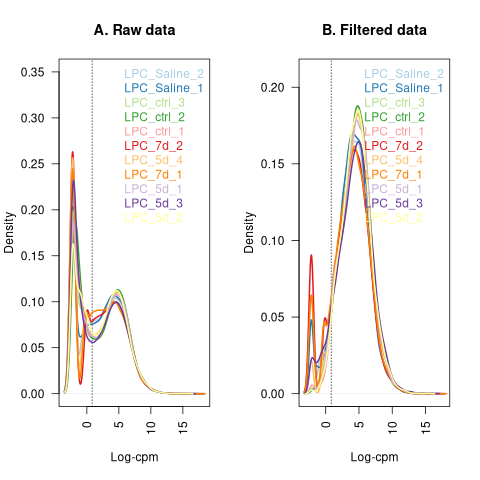

In [21]:
%%R
lcpm.cutoff <- log2(10/M + 2/L)
library(RColorBrewer)
nsamples <- ncol(x2)
col <- brewer.pal(nsamples, "Paired")

par(mfrow=c(1,2))

lcpm <- edgeR::cpm(x, log=TRUE)
plot(density(lcpm[,1]), col=col[1], lwd=2, ylim=c(0,0.35), las=2, main="", xlab="")
title(main="A. Raw data", xlab="Log-cpm")
abline(v=lcpm.cutoff, lty=3)
for (i in 2:nsamples){
  den <- density(lcpm[,i])
  lines(den$x, den$y, col=col[i], lwd=2)
}
legend("topright", samplenames, text.col=col, bty="n")

lcpm <- edgeR::cpm(x2, log=TRUE)
plot(density(lcpm[,1]), col=col[1], lwd=2, ylim=c(0,0.21), las=2, main="", xlab="")
title(main="B. Filtered data", xlab="Log-cpm")
abline(v=lcpm.cutoff, lty=3)
for (i in 2:nsamples){
  den <- density(lcpm[,i])
  lines(den$x, den$y, col=col[i], lwd=2)
}
legend("topright", samplenames, text.col=col, bty="n")

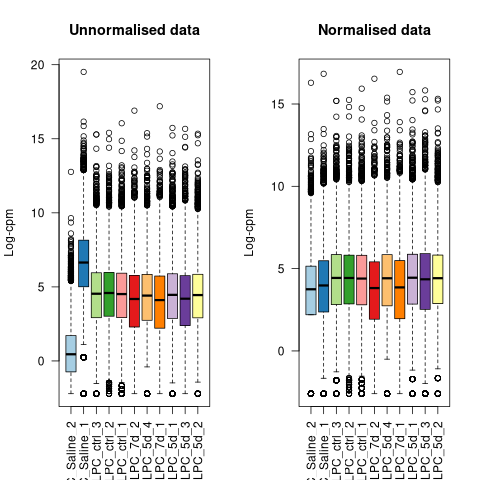

In [22]:
%%R
y2 <- x2
y2$samples$norm.factors <- 1
y2$counts[,1] <- ceiling(y2$counts[,1]*0.05)
y2$counts[,2] <- y2$counts[,2]*5

par(mfrow=c(1,2))
lcpm <- edgeR::cpm(y2, log=TRUE)
boxplot(lcpm, las=2, col=col, main="")
title(main="Unnormalised data", ylab="Log-cpm")

y3 <- calcNormFactors(y2)
y3$samples$norm.factors

lcpm <- edgeR::cpm(y3, log=TRUE)
boxplot(lcpm, las=2, col=col, main="")
title(main="Normalised data", ylab="Log-cpm")

# Show how log transf + batch removal affects the separation of samples:

In [23]:
%%R
cd <- x2$samples$group
print(cd)

 [1] ctrl ctrl ctrl ctrl ctrl stim stim stim stim stim stim
Levels: ctrl stim


In [24]:
%%R
#Make new count matrix with log counts and DGE data from X2 (trimmed, normfactors)
x3 <- x2
x3$counts <- lcpm

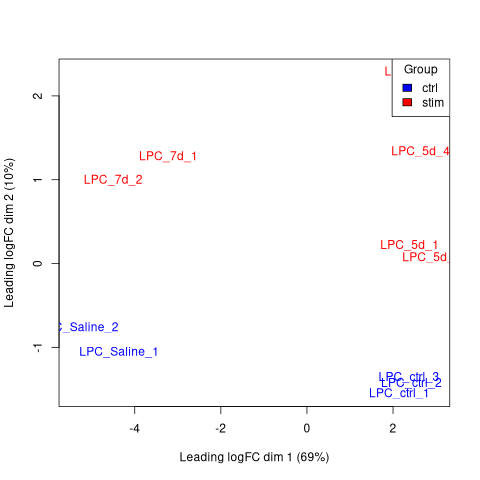

In [25]:
%%R
# Assuming 'group' is stored in y$samples dataframe
group <- x2$samples$group

# Generate a numeric vector from group factors (if not already factor, convert it)
group_factor <- as.factor(group)
group_colors <- as.numeric(group_factor)  # This converts factors to unique integers

# Define a set of colors corresponding to the factors
# Example: If you have two groups, you could define two colors
colors <- c("blue", "red")  # Adjust the number and colors based on your actual groups

# Use these colors in your plotMDS
plotMDS(x2, col = colors[group_colors])

# Adding a legend for clarity
legend("topright", legend=levels(group_factor), fill=colors, title="Group")

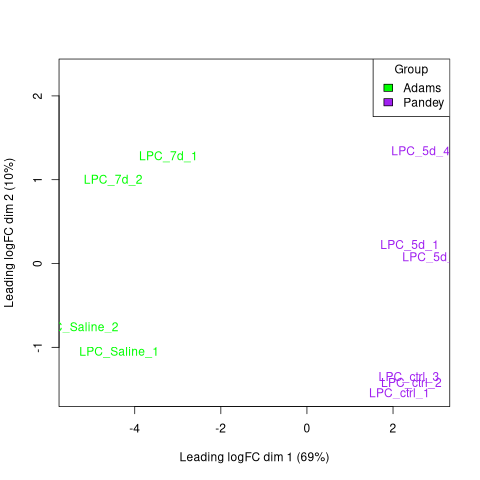

In [26]:
%%R
# Generate a numeric vector from group factors (if not already factor, convert it)
pub_factor <- as.factor(batch)
pub_colors <- as.numeric(pub_factor)  # This converts factors to unique integers

# Define a set of colors corresponding to the factors
# Example: If you have two groups, you could define two colors
colors <- c("green", "purple")  # Adjust the number and colors based on your actual groups

# Use these colors in your plotMDS
plotMDS(x2, col = colors[pub_colors])

# Adding a legend for clarity
legend("topright", legend=levels(pub_factor), fill=colors, title="Group")

In [28]:
%%R
# Adjust for batch-- ie publication in the model matrix
design <- model.matrix(~0 + cd)
design

   cdctrl cdstim
1       1      0
2       1      0
3       1      0
4       1      0
5       1      0
6       0      1
7       0      1
8       0      1
9       0      1
10      0      1
11      0      1
attr(,"assign")
[1] 1 1
attr(,"contrasts")
attr(,"contrasts")$cd
[1] "contr.treatment"



In [29]:
%%R
contr.matrix <- makeContrasts(cdstim - cdctrl, levels = colnames(design))
contr.matrix

        Contrasts
Levels   cdstim - cdctrl
  cdctrl              -1
  cdstim               1


In [30]:
%%R
# Convert to CPM and log2 transformation. 
logCPM <- edgeR::cpm(x2, log=TRUE, prior.count=3)

In [31]:
%%R
#Batch is set to the publication of origin to remove effects between sample origins
logCPM_no_batch <- removeBatchEffect(logCPM, batch=batch) 

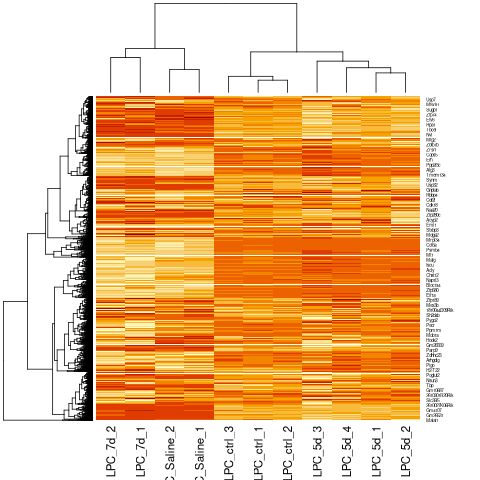

In [32]:
%%R
heatmap(logCPM)

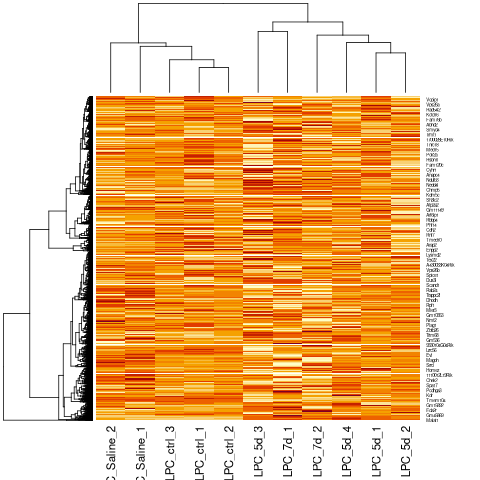

In [33]:
%%R
heatmap(logCPM_no_batch)

# Lets try with voom with a blocking variable:

In [32]:
%%R
# Adjust for batch-- ie publication in the model matrix
design <- model.matrix(~0 + cd)
design

   cdctrl cdstim
1       1      0
2       1      0
3       1      0
4       1      0
5       1      0
6       0      1
7       0      1
8       0      1
9       0      1
10      0      1
11      0      1
attr(,"assign")
[1] 1 1
attr(,"contrasts")
attr(,"contrasts")$cd
[1] "contr.treatment"



In [33]:
%%R
contr.matrix <- makeContrasts(cdstim - cdctrl, levels = colnames(design))
contr.matrix

        Contrasts
Levels   cdstim - cdctrl
  cdctrl              -1
  cdstim               1


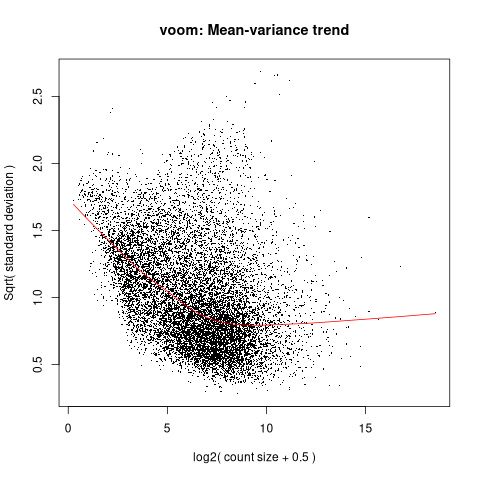

In [34]:
%%R
y <- voom(x2$counts, design, plot=TRUE, lib.size=colSums(x2$counts)*x2$samples$norm.factors)

In [35]:
%%R
corfit <- duplicateCorrelation(y,design,block=batch)
corfit$consensus.correlation

[1] 0.7804802


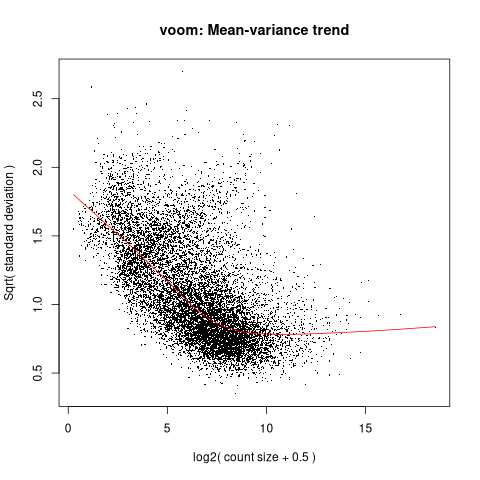

In [36]:
%%R
y2 <- voom(x2$counts, design, plot=TRUE, lib.size=colSums(x2$counts)*x2$samples$norm.factors,
          block=batch, correlation=corfit$consensus)

In [37]:
%%R
corfit2 <- duplicateCorrelation(y2,design,block=batch)
corfit2$consensus.correlation

[1] 0.7679273


In [38]:
%%R
fit <- lmFit(y2, design, block=batch, correlation=corfit2$consensus)

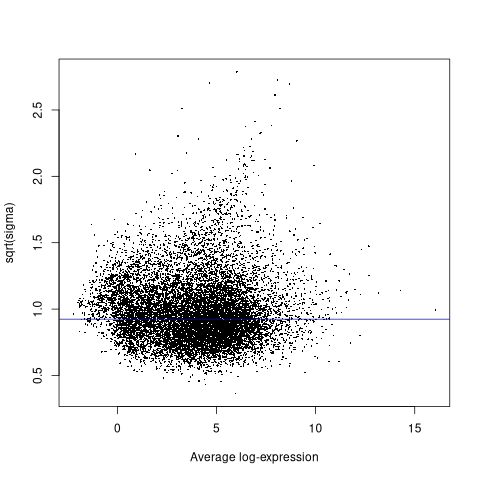

In [39]:
%%R
contr <- makeContrasts(cdstim - cdctrl, levels = colnames(coef(fit)))
tmp <- contrasts.fit(fit, contr)
tmp2 <- eBayes(tmp)

plotSA(tmp2, xlab = "Average log-expression", ylab = "sqrt(sigma)", zero.weights = FALSE,
       pch = 16, cex = 0.3, col = c("black","red"))

In [40]:
%%R
# Retrieve the top results without sorting by p-value directly
tt <- topTable(tmp2, sort.by = "P", n = Inf)
head(tt, 10)

            logFC  AveExpr        t      P.Value    adj.P.Val         B
Cachd1   2.622482 4.435629 17.93459 1.462548e-10 1.805955e-06 14.438882
Inppl1   1.781968 3.688280 13.67083 4.236261e-09 2.615468e-05 11.352632
Col16a1  2.780458 4.096699 13.07982 7.261332e-09 2.903009e-05 10.845652
Parp3    3.217810 3.119215 12.68124 1.057048e-08 2.903009e-05 10.260985
Irf9     2.759241 3.634661 12.57043 1.175498e-08 2.903009e-05 10.365731
Ldlrap1  2.015358 5.544381 12.23703 1.626024e-08 3.346357e-05 10.086930
Aldh1l2  2.428994 4.820938 11.60044 3.086604e-08 5.264060e-05  9.454361
Sema4g   2.266375 2.306655 11.29229 4.254494e-08 5.264060e-05  8.994383
Adamtsl3 2.713212 3.552552 11.18724 4.754219e-08 5.264060e-05  9.020133
Lhfpl3   2.714216 4.991184 11.08555 5.298208e-08 5.264060e-05  8.919850


In [41]:
%%R
length(which(tt$adj.P.Val < 0.05))

[1] 1005


In [42]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
significant_genes <- tt[tt$adj.P.Val < 0.05 & abs(tt$logFC) > 0.5, ]
num_significant_genes <- nrow(significant_genes)

# Print the number of significant genes
print(num_significant_genes)

[1] 982


In [43]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- tt[tt$adj.P.Val < 0.05 & tt$logFC > 0.7, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 618
                 logFC   AveExpr        t      P.Value    adj.P.Val          B
Nrcam         7.658160 1.0690299 7.530418 4.270844e-06 0.0005795207  2.3342915
Rgs20         7.587793 0.9413315 6.706093 1.446226e-05 0.0013128541  1.5553295
2310002F09Rik 7.463946 2.9666826 8.516562 1.108213e-06 0.0002359348  4.8799152
Steap3        7.439117 1.6253827 6.061716 3.996794e-05 0.0025838957  1.6615060
Sox5          7.218824 1.0908893 6.427088 2.230270e-05 0.0017540999  1.6899035
Chl1          7.144225 0.8821337 4.478323 6.192895e-04 0.0153246232 -0.6896801


In [44]:
%%R
if ('C4b' %in% rownames(genes_up_sorted)) {
    print("C4b is in the index of genes_up_sorted")
} else {
    print("C4b is not in the index of genes_up_sorted")
}

[1] "C4b is in the index of genes_up_sorted"


In [45]:
%%R
if ('Serpina3n' %in% rownames(genes_up_sorted)) {
    print("Serpina3n is in the index of genes_up_sorted")
} else {
    print("Serpina3n is not in the index of genes_up_sorted")
}

[1] "Serpina3n is in the index of genes_up_sorted"


In [46]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- tt[tt$adj.P.Val < 0.05 & tt$logFC < -0.7, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 213
           logFC    AveExpr         t      P.Value  adj.P.Val          B
Itgb5  -6.355570  1.3821039 -3.632913 0.0030280402 0.04234611 -1.8070157
Lcp1   -6.281705  1.4162829 -3.618583 0.0031121793 0.04298567 -1.8902263
Mtr    -5.636019  0.6523824 -4.028662 0.0014286657 0.02684871 -1.2913792
Irak2  -5.607563  1.2695499 -4.414799 0.0006959852 0.01655080 -0.7676753
Pycard -5.167249 -0.2300125 -4.611972 0.0004851628 0.01296708 -0.5762522
Cx3cr1 -5.166717  0.2685451 -3.984242 0.0015533652 0.02829620 -1.2626098


# Redo try with voom with quality weights

In [34]:
%%R
# Adjust for batch-- ie publication in the model matrix
design <- model.matrix(~0 + cd)
design

   cdctrl cdstim
1       1      0
2       1      0
3       1      0
4       1      0
5       1      0
6       0      1
7       0      1
8       0      1
9       0      1
10      0      1
11      0      1
attr(,"assign")
[1] 1 1
attr(,"contrasts")
attr(,"contrasts")$cd
[1] "contr.treatment"



In [35]:
%%R
contr.matrix <- makeContrasts(cdstim - cdctrl, levels = colnames(design))
contr.matrix

        Contrasts
Levels   cdstim - cdctrl
  cdctrl              -1
  cdstim               1


In [36]:
%%R
batch

LPC_Saline_2 LPC_Saline_1   LPC_ctrl_3   LPC_ctrl_2   LPC_ctrl_1     LPC_7d_2 
       Adams        Adams       Pandey       Pandey       Pandey        Adams 
    LPC_5d_4     LPC_7d_1     LPC_5d_1     LPC_5d_3     LPC_5d_2 
      Pandey        Adams       Pandey       Pandey       Pandey 
Levels: Adams Pandey


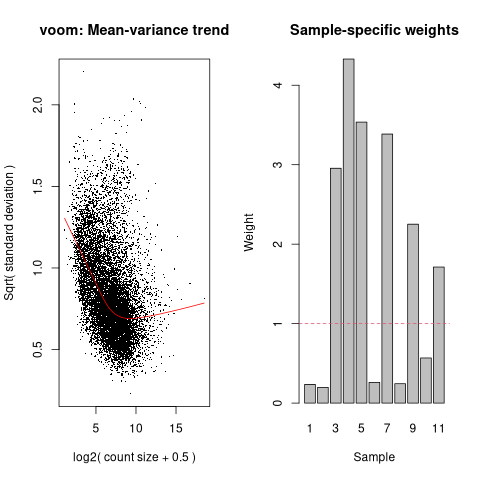

In [37]:
%%R
y <- voomWithQualityWeights(x2$counts, design, plot=TRUE)

In [38]:
%%R
corfit <- duplicateCorrelation(y, design, block=batch)
corfit$consensus.correlation

[1] 0.5351571


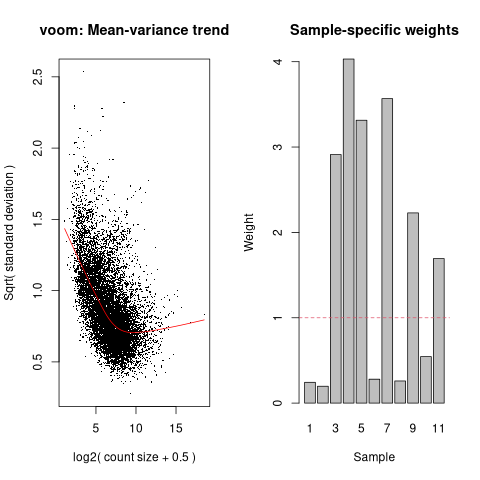

In [39]:
%%R
y2 <- voomWithQualityWeights(x2$counts, design, plot=TRUE, block=batch, correlation=corfit$consensus)

In [40]:
%%R
corfit2 <- duplicateCorrelation(y2,design, block=batch, weights=y2$targets$sample.weights)
corfit2$consensus.correlation

[1] 0.5935664


In [41]:
%%R
fit <- lmFit(y2, design, block=batch, correlation=corfit2$consensus)

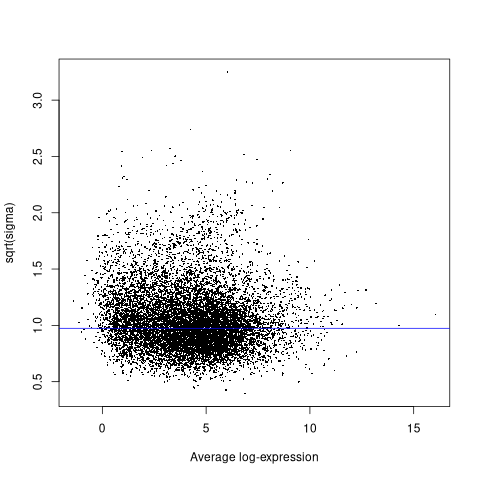

In [42]:
%%R
contr <- makeContrasts(cdstim - cdctrl, levels = colnames(coef(fit)))
tmp <- contrasts.fit(fit, contr)
tmp2 <- eBayes(tmp)

plotSA(tmp2, xlab = "Average log-expression", ylab = "sqrt(sigma)", zero.weights = FALSE,
       pch = 16, cex = 0.3, col = c("black","red"))

In [43]:
%%R
# Retrieve the top results without sorting by p-value directly
tt <- topTable(tmp2, sort.by = "P", n = Inf)
head(tt, 10)

             logFC  AveExpr        t      P.Value    adj.P.Val        B
Serpina3n 6.846376 6.343200 25.45141 2.798568e-12 2.293260e-08 18.66274
Masp1     3.692606 5.577334 24.74119 3.982737e-12 2.293260e-08 18.30314
C4b       4.153437 6.984800 23.12509 9.231433e-12 3.138267e-08 17.51491
Col16a1   2.868299 4.100386 22.81779 1.090055e-11 3.138267e-08 17.21186
Pros1     3.613816 4.020028 21.36942 2.458354e-11 5.662080e-08 16.49580
Cachd1    2.410952 4.439316 20.77188 3.491687e-11 6.701712e-08 16.17093
Rab3b     2.924800 4.391234 19.94949 5.750378e-11 9.460194e-08 15.68016
Fam13c    2.503608 7.179891 19.52602 7.491516e-11 1.078404e-07 15.44231
Lhfpl3    3.019617 4.994871 19.31500 8.564252e-11 1.095844e-07 15.30887
Cebpd     3.056127 4.614387 18.73272 1.247981e-10 1.437175e-07 14.93554


In [44]:
%%R
length(which(tt$adj.P.Val < 0.05))

[1] 1160


In [45]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
significant_genes <- tt[tt$adj.P.Val < 0.05 & abs(tt$logFC) > 0.7, ]
num_significant_genes <- nrow(significant_genes)

# Print the number of significant genes
print(num_significant_genes)

[1] 773


In [48]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_up <- tt[tt$adj.P.Val < 0.05 & tt$logFC > 0.7, ]
num_genes_up <- nrow(genes_up)

# Print the number of significant genes
print(num_genes_up)

genes_up_sorted <- genes_up[order(genes_up$logFC, decreasing = TRUE), ]

# View the head of the significant genes data frame
head(genes_up_sorted)

[1] 507
                  logFC    AveExpr         t      P.Value    adj.P.Val
Klk8          10.744879 1.64132833  5.690577 8.096621e-05 2.547560e-03
Bcan           8.397339 0.99045001 10.606034 1.123228e-07 1.596926e-05
Steap3         8.228042 1.62906943 12.324330 1.953390e-08 4.890269e-06
Rbp1           8.028440 0.48353055  6.036754 4.620989e-05 1.693585e-03
2310002F09Rik  7.941765 2.97036933 16.823036 4.654597e-10 4.123257e-07
S100a10        7.911535 0.02215022  6.821791 1.377176e-05 6.796417e-04
                      B
Klk8           1.804488
Bcan           7.322903
Steap3         8.674971
Rbp1           2.335981
2310002F09Rik 12.258141
S100a10        3.401865


In [49]:
%%R
if ('C4b' %in% rownames(genes_up_sorted)) {
    print("C4b is in the index of genes_up_sorted")
} else {
    print("C4b is not in the index of genes_up_sorted")
}

[1] "C4b is in the index of genes_up_sorted"


In [50]:
%%R
if ('Socs3' %in% rownames(genes_up_sorted)) {
    print("Socs3 is in the index of genes_up_sorted")
} else {
    print("Socs3 is not in the index of genes_up_sorted")
}

[1] "Socs3 is in the index of genes_up_sorted"


In [51]:
%%R
if ('Serpina3n' %in% rownames(genes_up_sorted)) {
    print("Serpina3n is in the index of genes_up_sorted")
} else {
    print("Serpina3n is not in the index of genes_up_sorted")
}

[1] "Serpina3n is in the index of genes_up_sorted"


In [52]:
%%R
if ('H2-D1' %in% rownames(genes_up_sorted)) {
    print("H2-D1 is in the index of genes_up_sorted")
} else {
    print("H2-D1 is not in the index of genes_up_sorted")
}

[1] "H2-D1 is in the index of genes_up_sorted"


In [53]:
%%R
if ('B2m' %in% rownames(genes_up_sorted)) {
    print("B2m is in the index of genes_up_sorted")
} else {
    print("B2m is not in the index of genes_up_sorted")
}

[1] "B2m is in the index of genes_up_sorted"


In [54]:
%%R
# Calculate the number of genes with adj.P.Val < 0.05 and |logFC| > 1
genes_down <- tt[tt$adj.P.Val < 0.05 & tt$logFC < -0.7, ]
num_genes_down <- nrow(genes_down)

# Print the number of significant genes
print(num_genes_down)

genes_down_sorted <- genes_down[order(genes_down$logFC, decreasing = FALSE), ]

# View the head of the significant genes data frame
head(genes_down_sorted)

[1] 266
            logFC    AveExpr         t      P.Value   adj.P.Val          B
Apbb1ip -5.736198  0.5415442 -5.672200 8.345217e-05 0.002611509  1.5504786
Milr1   -4.314998 -0.6820699 -5.664153 8.456580e-05 0.002632053  1.6515398
Tbxas1  -4.288400 -0.0851744 -5.731004 7.576775e-05 0.002439892  1.7093583
Itgb5   -4.176623  1.3857906 -4.188730 1.114551e-03 0.017901215 -0.6840360
Irak2   -4.079406  1.2732365 -4.997004 2.618962e-04 0.006180321  0.6936187
Nr4a1   -3.989545  0.6577627 -3.654562 3.018162e-03 0.035214945 -1.4904767


# Save output- make sure to rename!

In [55]:
%%R
# Add row names as a new column
tt$gene <- rownames(tt)

# Optionally reorder or select columns
tt <- tt[, c("gene", names(tt)[1:6])]

# Write to CSV file
write.table(tt, file = "./files/LPC_demyel_MOL_all_voom_wqw_UPDATED.csv", row.names = FALSE, sep = ",", quote = FALSE)